In [1]:
from matplotlib import pyplot as plt
import torch

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [3]:
from torchvision.transforms import v2
from torchvision.datasets import CIFAR10
from torch import nn

CIFAR_MEAN = (0.49145, 0.48219, 0.44658)
CIFAR_STD = (0.24687, 0.24332, 0.26137)

crop_transform = nn.ModuleList([
    v2.RandomCrop(
        size=32,
        padding=4
    )
])

train_transforms = v2.Compose([
    v2.RandomApply(crop_transform, p=0.8),
    v2.RandomHorizontalFlip(p=0.5),
    v2.ColorJitter(
        brightness=[0.6, 1.4],
        contrast=[0.6, 1.4],
        saturation=[0.6, 1.4]
    ),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=CIFAR_MEAN, std=CIFAR_STD)
])

test_transforms = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=CIFAR_MEAN, std=CIFAR_STD)
])

train_dataset = CIFAR10(
    root="../data",
    train=True,
    transform=train_transforms,
    download=True
)

test_dataset = CIFAR10(
    root="../data",
    train=False,
    transform=test_transforms,
    download=True
)

categories = tuple(train_dataset.classes)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.9802322e-08..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.9802322e-08..0.9294118].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.9802322e-08..0.9333334].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.9802322e-08..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.9802322e-08..0.6784314].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.9802322e-08..0.86666673].


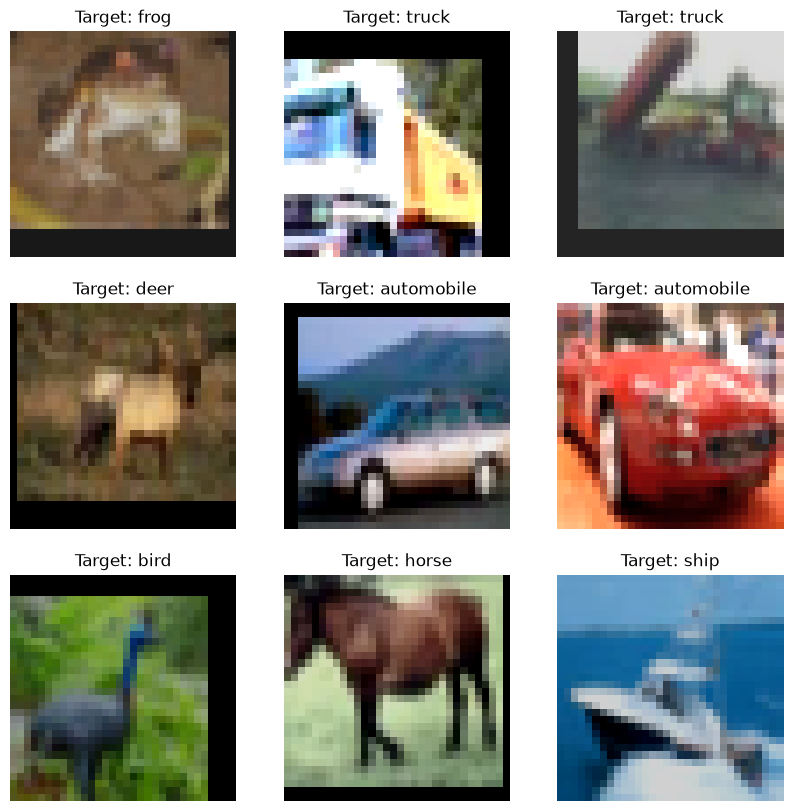

In [4]:
fig, axes = plt.subplots(3, 3, figsize=(10, 10))

for i, ax in enumerate(axes.flatten()):
    image, target = train_dataset[i]

    # un-standardize image
    cifar_std = torch.tensor(CIFAR_STD).view(3, 1, 1)
    cifar_mean = torch.tensor(CIFAR_MEAN).view(3, 1, 1)
    image = image * cifar_std
    image = image + cifar_mean
    image = image.permute(1, 2, 0)

    # display images
    ax.imshow(image)
    ax.axis(False)
    ax.set_title(f"Target: {categories[target]}")

plt.show()

In [5]:
from torch.utils.data import DataLoader, random_split

# create validation set 
generator = torch.Generator().manual_seed(7)
train_dataset, val_dataset = random_split(train_dataset, [0.8, 0.2], generator=generator)

# create DataLoader objects
train_dl = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_dl = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_dl = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [6]:
from pathlib import Path
import sys

sys.path.append(str(Path.cwd().parent))

In [7]:
from src.model import VisionTransformer

device = "cuda" if torch.cuda.is_available() else "cpu"

print(device)

model = VisionTransformer().to(device, non_blocking=True)
model

cuda


VisionTransformer(
  (conv_layer): Conv2d(3, 512, kernel_size=(4, 4), stride=(4, 4))
  (dropout): Dropout(p=0.0, inplace=False)
  (transformer_encoder): TransformerEncoder(
    (transformer_layers): ModuleList(
      (0-3): 4 x TransformerLayer(
        (layer_norm_1): LayerNorm((512,), eps=1e-05, elementwise_affine=True, bias=True)
        (layer_norm_2): LayerNorm((512,), eps=1e-05, elementwise_affine=True, bias=True)
        (multi_head_self_attention): MultiHeadSelfAttention(
          (self_attention_heads): ModuleList(
            (0-3): 4 x SelfAttentionHead(
              (Q_linear_transform): Linear(in_features=512, out_features=128, bias=False)
              (K_linear_transform): Linear(in_features=512, out_features=128, bias=False)
              (V_linear_transform): Linear(in_features=512, out_features=128, bias=False)
            )
          )
          (output_linear_transform): Linear(in_features=512, out_features=512, bias=False)
        )
        (mlp): MLP(
          

In [9]:
from src.inference_functions import compute_accuracy

compute_accuracy(model, test_dl, device)

0.08320000022649765

In [13]:
len(train_dl)

1250